# Country Internet Connectivity — Disruption Analysis (Cloudflare Radar)

This notebook uses the **Cloudflare Radar API** to monitor internet traffic and
connectivity in **any country** and to surface **sudden drops or outages**.

Pick any country in the configuration cell — the same pipeline works for any of
the 200+ ISO alpha-2 country codes supported by Cloudflare Radar (e.g. `US`,
`BR`, `IR`, `KE`, `IN`, `RU`, `EG`).

Government-imposed internet shutdowns are a well-documented tactic during periods
of civil unrest: when traffic from an entire country collapses abruptly — outside
of normal daily patterns — it can indicate a deliberate, large-scale disruption.
Organizations such as Cloudflare Radar, NetBlocks, OONI, and the IODA project
track exactly these signals to support digital-rights and transparency reporting.

**What this notebook does**
1. Pulls the selected country's HTTP request and network-traffic time series.
2. Plots them so daily rhythms and anomalies are visible.
3. Runs a simple anomaly detector that flags abnormal traffic *drops*.
4. Fetches Cloudflare's curated **outage annotations** for the country and
   suppresses already-known outage windows from the detector output.
5. Pulls the **Internet Quality Index** (latency / bandwidth) as a secondary signal.
6. Summarizes the *new* (not previously curated) suspected disruption windows.

> **Scope & ethics.** This is an observational, read-only analysis of publicly
> reported aggregate network data. A traffic drop is *evidence* of disruption, not
> proof of intent — confirm against multiple sources (NetBlocks, OONI, news
> reporting) before drawing conclusions.

## 1. Setup

Install dependencies (safe to re-run) and import libraries.

In [1]:
# Run once; comment out after the first execution.
%pip install -q requests pandas matplotlib python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import datetime as dt
from typing import Optional

import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Auto-load a sibling .env file when python-dotenv is available, so you only
# have to fill in .env once instead of exporting env vars every time.
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.figsize'] = (13, 4.5)
plt.rcParams['axes.grid'] = True

## 2. API token

Get a token from the [Cloudflare dashboard](https://dash.cloudflare.com/profile/api-tokens)
— the **Radar Read** permission is enough. **Do not paste it into the notebook.**

Easiest path: copy `.env.example` to `.env` next to this notebook and fill in
the value. The previous cell auto-loads it (via `python-dotenv`).

Alternatively, set the environment variable before launching Jupyter:

```bash
# macOS / Linux
export CLOUDFLARE_API_TOKEN="your_token_here"

# Windows PowerShell
$env:CLOUDFLARE_API_TOKEN = "your_token_here"
```

If neither is set, the cell below will prompt you securely.

In [3]:
API_TOKEN = os.environ.get('CLOUDFLARE_API_TOKEN')

if not API_TOKEN:
    import getpass
    API_TOKEN = getpass.getpass('Enter your Cloudflare API token: ').strip()

assert API_TOKEN, 'A Cloudflare API token is required.'
print('Token loaded (length: %d).' % len(API_TOKEN))

Token loaded (length: 53).


## 3. Configuration & API client

Pick the country you want to analyse and the look-back window. You can either set
the env vars `CFR_LOCATION` / `CFR_DATE_RANGE` before launching Jupyter, or just
let the cell prompt you.

- `LOCATION`: any 2-letter **ISO alpha-2** country code (e.g. `US`, `BR`, `IR`).
- `DATE_RANGE`: Cloudflare Radar window, e.g. `7d`, `14d`, `28d`, `90d`, `52w`.
- `AGG_INTERVAL`: `1h` is recommended for hourly outage resolution.

In [4]:
BASE_URL = 'https://api.cloudflare.com/client/v4/radar'

# --- User configuration -----------------------------------------------------
# 1. Country: any 2-letter ISO alpha-2 code (US, BR, IR, KE, IN, RU, EG, ...).
#    Set env var CFR_LOCATION to skip the prompt (useful for batch runs).
LOCATION = (os.environ.get('CFR_LOCATION')
            or input('Enter 2-letter country code (e.g. US, BR, IR): ')).strip().upper()
assert len(LOCATION) == 2 and LOCATION.isalpha(), 'LOCATION must be a 2-letter ISO code'

# 2. Look-back window. Cloudflare Radar accepts e.g. 7d, 14d, 28d, 90d, 52w.
DATE_RANGE = (os.environ.get('CFR_DATE_RANGE')
              or input('Date range [default 28d]: ')).strip() or '28d'

# 3. Aggregation interval. 1h is the most useful for hourly-resolution outages.
AGG_INTERVAL = os.environ.get('CFR_AGG_INTERVAL', '1h')
# ----------------------------------------------------------------------------

HEADERS = {'Authorization': f'Bearer {API_TOKEN}', 'Content-Type': 'application/json'}


def radar_get(path: str, params: Optional[dict] = None) -> dict:
    """GET a Cloudflare Radar endpoint and return the `result` payload."""
    resp = requests.get(f'{BASE_URL}/{path.lstrip("/")}', headers=HEADERS,
                        params=params or {}, timeout=30)
    if resp.status_code != 200:
        raise RuntimeError(f'{resp.status_code} for {path}: {resp.text[:400]}')
    payload = resp.json()
    if not payload.get('success', False):
        raise RuntimeError(f'API error for {path}: {payload.get("errors")}')
    return payload['result']


def series_to_frame(result: dict, value_name: str = 'value') -> pd.DataFrame:
    """Convert a Radar timeseries `result` (serie_0) into a tidy DataFrame."""
    serie = result.get('serie_0') or next(
        (v for k, v in result.items() if k.startswith('serie')), None)
    if not serie:
        raise ValueError('No timeseries found in result.')
    df = pd.DataFrame({
        'timestamp': pd.to_datetime(serie['timestamps'], utc=True),
        value_name: pd.to_numeric(serie['values'], errors='coerce'),
    })
    return df.set_index('timestamp').sort_index()


print(f'Client ready. Target: {LOCATION} | range: {DATE_RANGE} | agg: {AGG_INTERVAL}')

Client ready. Target: IR | range: 28d | agg: 1h


## 4. HTTP request traffic

Relative HTTP request volume from the selected country. Healthy traffic shows a
smooth diurnal (day/night) cycle; a near-vertical cliff that doesn't match that
rhythm is the classic signature of a shutdown.

In [5]:
http_res = radar_get('http/timeseries', {
    'location': LOCATION,
    'dateRange': DATE_RANGE,
    'aggInterval': AGG_INTERVAL,
})
http_df = series_to_frame(http_res, 'http_requests')
print(f'{len(http_df)} points from {http_df.index.min()} to {http_df.index.max()}')
http_df.tail()

672 points from 2026-05-14 16:00:00+00:00 to 2026-06-11 15:00:00+00:00


,http_requests
timestamp,
2026-06-11 11:00:00+00:00,0.694229
2026-06-11 12:00:00+00:00,0.654197
2026-06-11 13:00:00+00:00,0.621856
2026-06-11 14:00:00+00:00,0.594323
2026-06-11 15:00:00+00:00,0.585700


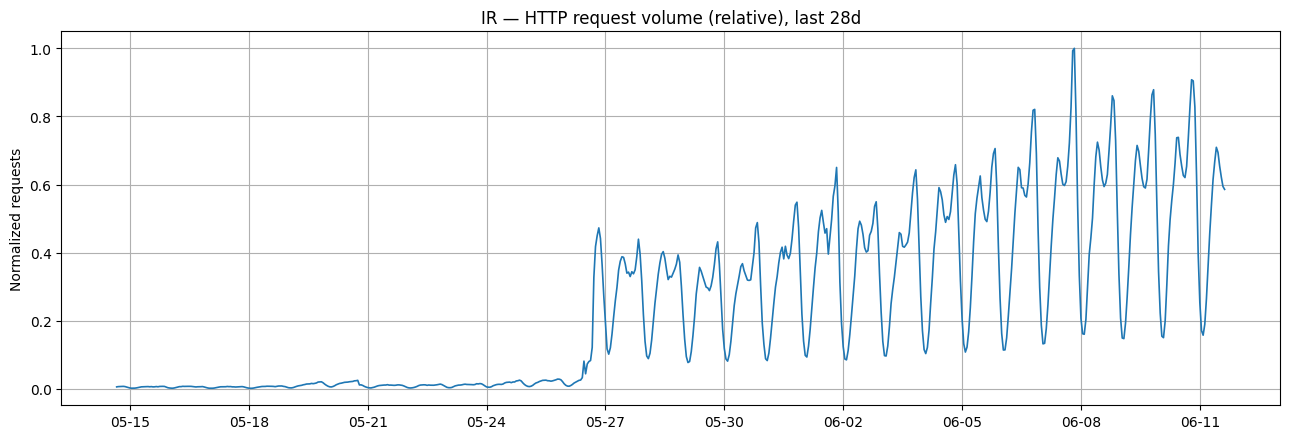

In [6]:
ax = http_df['http_requests'].plot(color='#1f77b4', lw=1.2, x_compat=True)
ax.set_title(f'{LOCATION} — HTTP request volume (relative), last {DATE_RANGE}')
ax.set_ylabel('Normalized requests')
ax.set_xlabel('')
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax.get_xticklabels(), rotation=0, ha='center')
plt.tight_layout(); plt.show()

## 5. Network traffic (NetFlows)

A second, independent volume signal derived from network flow data. Cross-checking
HTTP against NetFlows reduces the chance that a dip is just a measurement artifact.

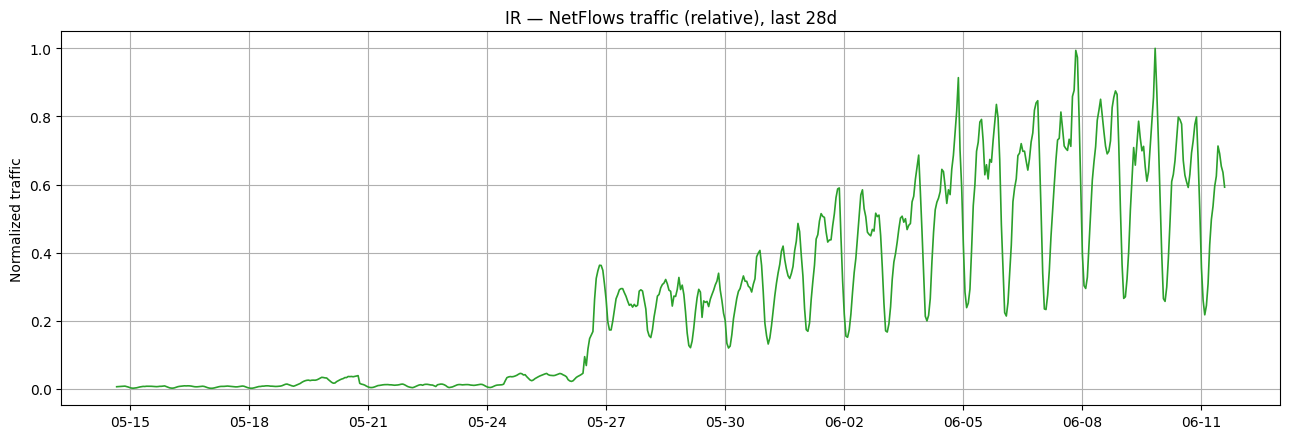

In [7]:
try:
    nf_res = radar_get('netflows/timeseries', {
        'location': LOCATION,
        'dateRange': DATE_RANGE,
        'aggInterval': AGG_INTERVAL,
        'product': 'HTTP',
    })
    nf_df = series_to_frame(nf_res, 'netflows')
    ax = nf_df['netflows'].plot(color='#2ca02c', lw=1.2, x_compat=True)
    ax.set_title(f'{LOCATION} — NetFlows traffic (relative), last {DATE_RANGE}')
    ax.set_ylabel('Normalized traffic'); ax.set_xlabel('')
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.setp(ax.get_xticklabels(), rotation=0, ha='center')
    plt.tight_layout(); plt.show()
except RuntimeError as e:
    nf_df = None
    print('NetFlows unavailable for this token/range:', e)

## 6. Anomaly detection — flag abnormal traffic drops

We compare each point to a rolling **median baseline** (robust to spikes) and the
rolling **MAD** (median absolute deviation). A point is flagged as a *suspected
disruption* when traffic falls well below baseline by both a relative threshold
(e.g. <50% of baseline) and a statistical one (a strong negative robust z-score).

Tune `DROP_RATIO` and `Z_THRESHOLD` for sensitivity.

In [8]:
WINDOW      = 24      # baseline window in points (24 = ~1 day at 1h interval)
DROP_RATIO  = 0.50    # flag if value < 50% of rolling-median baseline
Z_THRESHOLD = 3.5     # robust z-score magnitude for a 'large' deviation


def detect_drops(df: pd.DataFrame, col: str) -> pd.DataFrame:
    s = df[col].astype(float)
    baseline = s.rolling(WINDOW, min_periods=WINDOW // 2, center=True).median()
    mad = (s - baseline).abs().rolling(WINDOW, min_periods=WINDOW // 2,
                                       center=True).median()
    robust_z = 0.6745 * (s - baseline) / mad.replace(0, pd.NA)
    out = pd.DataFrame({
        col: s, 'baseline': baseline, 'robust_z': robust_z,
        'pct_of_baseline': s / baseline,
    })
    out['disruption'] = (out['pct_of_baseline'] < DROP_RATIO) & (out['robust_z'] < -Z_THRESHOLD)
    return out


flagged = detect_drops(http_df, 'http_requests')
n_flags = int(flagged['disruption'].sum())
print(f'Suspected disruption points (raw): {n_flags}')
flagged[flagged['disruption']].head(20)

Suspected disruption points (raw): 13


,http_requests,baseline,robust_z,pct_of_baseline,disruption
timestamp,,,,,
2026-05-17 00:00:00+00:00,0.001743,0.005788,-3.942219,0.301166,True
2026-05-17 01:00:00+00:00,0.001574,0.005788,-4.262476,0.271965,True
2026-05-17 02:00:00+00:00,0.001691,0.005788,-4.144116,0.292181,True
2026-05-17 03:00:00+00:00,0.002131,0.005687,-4.017060,0.374747,True
2026-05-19 01:00:00+00:00,0.002694,0.007260,-3.713206,0.371049,True
2026-05-22 00:00:00+00:00,0.003828,0.010301,-3.537675,0.371596,True
2026-05-22 01:00:00+00:00,0.002707,0.010173,-4.640995,0.266110,True
2026-05-22 02:00:00+00:00,0.002395,0.010173,-4.834953,0.235439,True
2026-05-22 03:00:00+00:00,0.002890,0.010173,-4.527232,0.284099,True


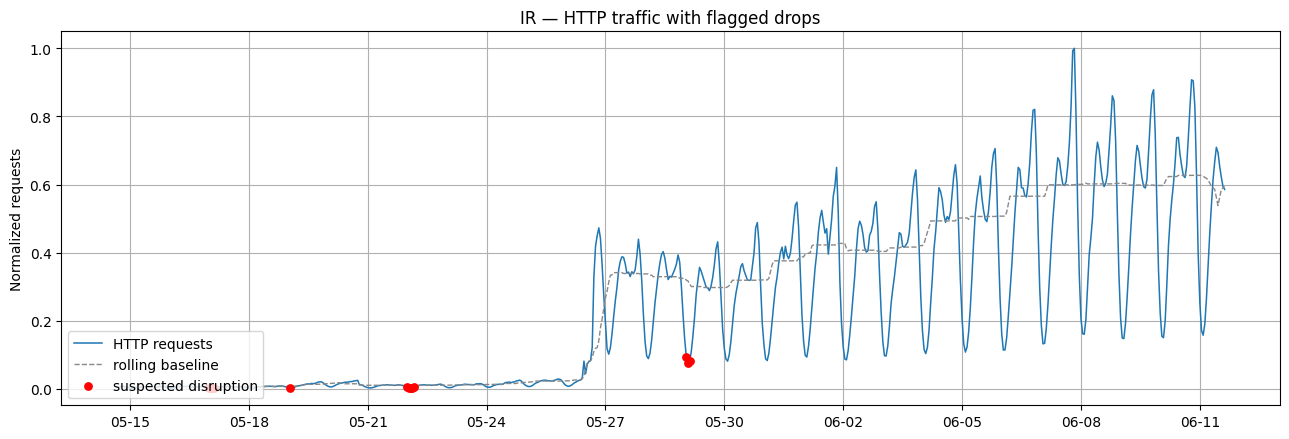

In [9]:
ax = flagged['http_requests'].plot(color='#1f77b4', lw=1.1, label='HTTP requests', x_compat=True)
flagged['baseline'].plot(ax=ax, color='#888', lw=1.0, ls='--', label='rolling baseline', x_compat=True)
hits = flagged[flagged['disruption']]
ax.scatter(hits.index, hits['http_requests'], color='red', s=28, zorder=5,
           label='suspected disruption')
ax.set_title(f'{LOCATION} — HTTP traffic with flagged drops')
ax.set_ylabel('Normalized requests'); ax.set_xlabel('')
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax.get_xticklabels(), rotation=0, ha='center')
ax.legend(loc='lower left'); plt.tight_layout(); plt.show()

### Group flagged points into disruption windows

Consecutive flagged hours are merged into a single event with start, end and a
severity estimate (how far traffic fell below baseline).

In [10]:
# Fetch curated outage annotations first so we can suppress flagged windows
# that fall inside an already-known outage (they're the same event, not new).
ann_res = radar_get('annotations/outages', {
    'location': LOCATION,
    'dateRange': '52w',
    'limit': 50,
})
annotations = ann_res.get('annotations', [])
now_utc = pd.Timestamp.utcnow().tz_localize(None).tz_localize('UTC')
known_outages = [
    (pd.to_datetime(a['startDate'], utc=True),
     pd.to_datetime(a['endDate'], utc=True) if a.get('endDate') else now_utc)
    for a in annotations
]


def _inside_known(start, end, known):
    return any(s <= end and start <= e for s, e in known)


def group_windows(flagged_df: pd.DataFrame, gap: str = '2h',
                  known=None) -> pd.DataFrame:
    hits = flagged_df[flagged_df['disruption']].copy()
    if hits.empty:
        return pd.DataFrame(columns=['start', 'end', 'duration_h',
                                     'min_pct_of_baseline', 'inside_known_outage'])
    gap_td = pd.Timedelta(gap)
    new_event = hits.index.to_series().diff() > gap_td
    hits['event'] = new_event.cumsum()
    rows = []
    for _, grp in hits.groupby('event'):
        start, end = grp.index.min(), grp.index.max()
        rows.append({
            'start': start, 'end': end,
            'duration_h': round((end - start).total_seconds() / 3600 + 1, 1),
            'min_pct_of_baseline': round(float(grp['pct_of_baseline'].min()) * 100, 1),
            'inside_known_outage': _inside_known(start, end, known or []),
        })
    return pd.DataFrame(rows)


windows_all = group_windows(flagged, known=known_outages)
windows = windows_all[~windows_all['inside_known_outage']].reset_index(drop=True)

print(f'Raw windows: {len(windows_all)} | '
      f'suppressed (inside known outage): {int(windows_all["inside_known_outage"].sum())} | '
      f'new: {len(windows)}')
windows

Raw windows: 4 | suppressed (inside known outage): 3 | new: 1


,start,end,duration_h,min_pct_of_baseline,inside_known_outage
0,2026-05-29 01:00:00+00:00,2026-05-29 03:00:00+00:00,3.0,24.4,False


## 7. Cloudflare outage annotations

Cloudflare curates a list of confirmed internet outages with cause and scope.
Cross-referencing your flagged windows against these annotations is the strongest
single corroboration available inside Radar.

In [11]:
# Annotations already fetched above for window suppression; display them here.
print(f'{len(annotations)} outage annotation(s) for {LOCATION}.')

if annotations:
    out_df = pd.json_normalize(annotations)
    keep = [c for c in ['startDate', 'endDate', 'eventType', 'outage.outageCause',
                        'outage.outageType', 'description', 'linkedUrl']
            if c in out_df.columns]
    display(out_df[keep])
else:
    print('No curated outages in this window (absence is not proof of none).')

10 outage annotation(s) for IR.


,startDate,endDate,eventType,outage.outageCause,outage.outageType,description,linkedUrl
0,2026-02-28T07:00:00Z,2026-05-26T12:00:00Z,OUTAGE,GOVERNMENT_DIRECTED,NATIONWIDE,Iran Internet shutdown amid military actions,https://x.com/CloudflareRadar/status/2027709437981450502?s=20
1,2026-01-08T16:30:00Z,2026-02-01T00:00:00Z,OUTAGE,GOVERNMENT_DIRECTED,NATIONWIDE,Widespread disruption follows earlier loss of IPv6 connectivity amid protests,https://x.com/CloudflareRadar/status/2009312093749801350
2,2025-07-05T21:15:00Z,2025-07-06T00:00:00Z,OUTAGE,UNKNOWN,NATIONWIDE,Internet disruption in Iran following a reported DDoS attack,https://x.com/CloudflareRadar/status/1941640046005617038
3,2025-06-18T12:50:00Z,2025-06-25T05:00:00Z,OUTAGE,GOVERNMENT_DIRECTED,NATIONWIDE,Internet reportedly cut off again across Iran,https://bsky.app/profile/radar.cloudflare.com/post/3lrv55cxsb222
4,2025-06-17T14:00:00Z,2025-06-18T06:00:00Z,OUTAGE,GOVERNMENT_DIRECTED,NATIONWIDE,Internet connectivity reportedly (further) cut off in Iran,https://bsky.app/profile/radar.cloudflare.com/post/3lrsqwvlqa226
5,2025-06-17T14:00:00Z,2025-06-17T22:00:00Z,OUTAGE,GOVERNMENT_DIRECTED,NATIONWIDE,Internet connectivity reportedly (further) cut off in Iran,https://bsky.app/profile/radar.cloudflare.com/post/3lrsqwvlqa226
6,2025-06-17T14:00:00Z,2025-06-17T15:00:00Z,OUTAGE,GOVERNMENT_DIRECTED,NATIONWIDE,Internet connectivity reportedly (further) cut off in Iran,https://bsky.app/profile/radar.cloudflare.com/post/3lrsqwvlqa226
7,2025-06-17T14:00:00Z,2025-06-17T15:30:00Z,OUTAGE,GOVERNMENT_DIRECTED,NATIONWIDE,Internet connectivity reportedly (further) cut off in Iran,https://bsky.app/profile/radar.cloudflare.com/post/3lrsqwvlqa226
8,2025-06-17T14:00:00Z,2025-06-17T20:00:00Z,OUTAGE,GOVERNMENT_DIRECTED,NATIONWIDE,Internet connectivity reportedly (further) cut off in Iran,https://bsky.app/profile/radar.cloudflare.com/post/3lrsqwvlqa226
9,2025-06-13T07:15:00Z,2025-06-13T09:45:00Z,OUTAGE,GOVERNMENT_DIRECTED,NATIONWIDE,Internet access disrupted following Israel's attack,https://x.com/CloudflareRadar/status/1933461661660184818


## 8. Internet Quality Index (secondary signal)

During throttling (as opposed to a full cutoff), volume may stay up while
**latency rises** and **bandwidth falls**. The IQI captures that.

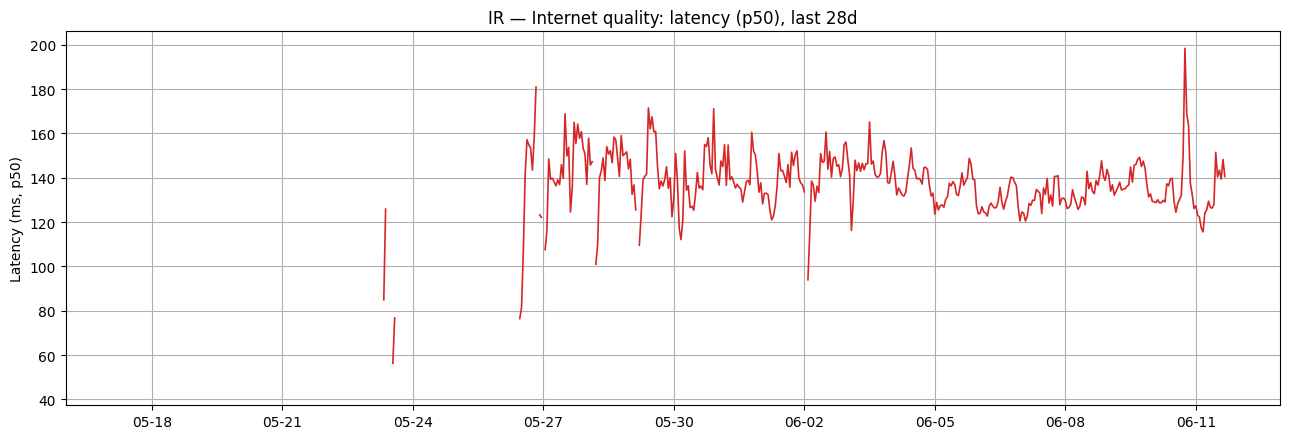

In [12]:
try:
    iqi_res = radar_get('quality/iqi/timeseries_groups', {
        'location': LOCATION,
        'dateRange': DATE_RANGE,
        'metric': 'latency',
    })
    serie = iqi_res.get('serie_0') or next(
        (v for k, v in iqi_res.items() if k.startswith('serie')), None)
    ts = pd.to_datetime(serie['timestamps'], utc=True)
    value_key = next((k for k in ('p50', 'p25', 'p75', 'values') if k in serie), None)
    iqi_df = pd.DataFrame({'latency_ms': pd.to_numeric(serie[value_key], errors='coerce')},
                          index=ts).sort_index()
    ax = iqi_df['latency_ms'].plot(color='#d62728', lw=1.2, x_compat=True)
    ax.set_title(f'{LOCATION} — Internet quality: latency ({value_key}), last {DATE_RANGE}')
    ax.set_ylabel(f'Latency (ms, {value_key})'); ax.set_xlabel('')
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.setp(ax.get_xticklabels(), rotation=0, ha='center')
    plt.tight_layout(); plt.show()
except Exception as e:
    iqi_df = None
    print('IQI unavailable for this token/range:', e)

## 9. Summary

Pull the findings together into a short report.

In [13]:
print('=' * 64)
print(f'  {LOCATION} connectivity report — generated {dt.datetime.utcnow():%Y-%m-%d %H:%M} UTC')
print('=' * 64)
print(f'Window analysed     : {http_df.index.min():%Y-%m-%d} -> {http_df.index.max():%Y-%m-%d}')
print(f'Data points (HTTP)  : {len(http_df)}')
print(f'Flagged drop hours  : {int(flagged["disruption"].sum())}')
print(f'Raw windows         : {len(windows_all)}')
print(f'Suppressed (known)  : {int(windows_all["inside_known_outage"].sum())}')
print(f'New windows         : {len(windows)}')
print(f'Curated outages     : {len(annotations)}')
print('-' * 64)
if len(windows):
    print('NEW suspected disruption windows (not overlapping known outages):')
    for _, w in windows.iterrows():
        print(f'  - {w.start:%Y-%m-%d %H:%M} -> {w.end:%H:%M} UTC '
              f'({w.duration_h}h, low {w.min_pct_of_baseline}% of baseline)')
else:
    print('No new disruption windows beyond the curated outage list.')
print('-' * 64)
print('Reminder: corroborate against NetBlocks / OONI / news before concluding intent.')

  IR connectivity report — generated 2026-06-11 17:25 UTC
Window analysed     : 2026-05-14 -> 2026-06-11
Data points (HTTP)  : 672
Flagged drop hours  : 13
Raw windows         : 4
Suppressed (known)  : 3
New windows         : 1
Curated outages     : 10
----------------------------------------------------------------
NEW suspected disruption windows (not overlapping known outages):
  - 2026-05-29 01:00 -> 03:00 UTC (3.0h, low 24.4% of baseline)
----------------------------------------------------------------
Reminder: corroborate against NetBlocks / OONI / news before concluding intent.


---
### Next steps & references
- Widen `DATE_RANGE` (e.g. `52w`) to cover a specific historical event and re-run.
- Break down by **ASN** (mobile vs fixed-line operators) to spot targeted shutdowns.
- Try the same notebook for a different country by changing `LOCATION` (or env var).
- Corroborate with: [Cloudflare Radar](https://radar.cloudflare.com/),
  [NetBlocks](https://netblocks.org/),
  [OONI Explorer](https://explorer.ooni.org/),
  [IODA](https://ioda.inetintel.cc.gatech.edu/).
- API docs: <https://developers.cloudflare.com/radar/>